In [ ]:
# -*- coding: utf-8 -*-
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
import logging
from sklearn.metrics import confusion_matrix, classification_report

# ==============================================================================
# SETUP LOGGING & KONFIGURASI
# ==============================================================================
logging.basicConfig(level=logging.INFO, format='[%(levelname)s]: %(message)s')
logger = logging.getLogger(__name__)

# --- PATH KONFIGURASI ---
INDONESIA_NOISE_JSON = "/Volumes/Extreme SSD/json_juli_1c_3c/extracted_data_3c_sesi_clean.json"
STEAD_GLOBAL_JSON = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json"
BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")

# --- PARAMETER INCREMENTAL LEARNING ---
BUFFER_SIZE = 100
CONFIDENCE_THRESHOLD = 0.85
TARGET_TPR_MIN = 0.98
INPUT_LENGTH = 700

# --- BASELINE UUSS (dari paper) ---
BASELINE_MEAN = 1.01
BASELINE_VAR = 0.49 ** 2

# ==============================================================================
# 1. EKSTRAKSI FITUR DENGAN P-ARRIVAL ALIGNMENT
# ==============================================================================
def load_json_and_extract_features(json_path, model, data_type="noise"):
    """
    Memuat JSON dan mengekstrak embedding dari MCU-Quake.
    - data_type="noise": ambil Z_noise, potong 700 sampel sebelum P
    - data_type="quake": ambil Z, potong 700 sampel setelah P
    """
    logger.info(f"Memuat dan mengekstrak fitur dari: {os.path.basename(json_path)}")
    latent_features = []
    
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        for key, record in data.items():
            # Tentukan key berdasarkan tipe data
            if data_type == "noise":
                key_signal = "Z_noise"
            else:
                key_signal = "Z"
            
            if key_signal not in record:
                continue
            
            signal = np.array(record[key_signal])
            
            # Validasi panjang
            if len(signal) < INPUT_LENGTH:
                continue
            
            # Ambil 700 sampel terakhir (noise) atau 700 sampel pertama (gempa)
            if data_type == "noise":
                signal = signal[-INPUT_LENGTH:]
            else:
                signal = signal[:INPUT_LENGTH]
            
            # Reshape
            signal_reshaped = signal.reshape(1, INPUT_LENGTH, 1)
            
            # Ekstraksi embedding
            feature = model.predict(signal_reshaped, verbose=0)
            latent_features.append(feature.flatten()[0])
            
    except Exception as e:
        logger.error(f"Gagal memuat {json_path}: {e}")
    
    return np.array(latent_features)

# ==============================================================================
# 2. PLASTISITAS: UPDATE DENGAN TEDA-RLS (FORMULA EKSAK)
# ==============================================================================
def recursive_statistical_update(mean_awal, var_awal, noise_features, forgetting_factor=0.99):
    """
    Update mean dan variance menggunakan TEDA-RLS dengan forgetting factor.
    """
    logger.info("Mengeksekusi Fase Plastisitas (TEDA-RLS Update)...")
    
    if len(noise_features) == 0:
        logger.warning("Tidak ada data noise untuk update.")
        return mean_awal, var_awal
    
    mu = mean_awal
    sigma2 = var_awal
    k = 0
    
    for feature in noise_features:
        k += 1
        delta = feature - mu
        # RLS update
        mu = mu + (1 - forgetting_factor) * delta
        sigma2 = (forgetting_factor * sigma2) + ((1 - forgetting_factor) * (delta ** 2))
        if sigma2 < 1e-9:
            sigma2 = 1e-9
    
    logger.info(f"Update selesai: Mean={mu:.4f}, Variance={sigma2:.4f}")
    return mu, sigma2

# ==============================================================================
# 3. STABILITAS: EVALUASI DENGAN CONFUSION MATRIX
# ==============================================================================
def evaluate_stability(mean_baru, var_baru, quake_features, noise_features=None):
    """
    Uji stabilitas model setelah update.
    """
    logger.info("Mengeksekusi Fase Stabilitas...")
    
    threshold = 3.0 * np.sqrt(var_baru)
    
    # Prediksi pada data gempa
    y_true = []
    y_pred = []
    
    # Gempa: seharusnya terdeteksi (label 1)
    for feat in quake_features:
        distance = np.abs(feat - mean_baru)
        y_true.append(1)
        y_pred.append(1 if distance > threshold else 0)
    
    # Noise: seharusnya tidak terdeteksi (label 0)
    if noise_features is not None:
        for feat in noise_features:
            distance = np.abs(feat - mean_baru)
            y_true.append(0)
            y_pred.append(0 if distance <= threshold else 1)
    
    # Metrik
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    f1 = 2 * (ppv * tpr) / (ppv + tpr) if (ppv + tpr) > 0 else 0.0
    
    return tpr, tnr, ppv, accuracy, f1

# ==============================================================================
# 4. MAIN PIPELINE
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "="*75)
    print("🚀 STABILITY-PLASTICITY TEST (INCREMENTAL LEARNING)")
    print("="*75)
    
    # --- 1. Load Model ---
    logger.info("Memuat model MCU-Quake...")
    try:
        frozen_model = keras.models.load_model(MODEL_PATH, compile=False)
    except Exception as e:
        logger.error(f"Gagal memuat model: {e}")
        exit(1)
    
    # --- 2. Ekstraksi Fitur Noise Indonesia ---
    indonesia_noise = load_json_and_extract_features(INDONESIA_NOISE_JSON, frozen_model, data_type="noise")
    logger.info(f"Jumlah sampel noise Indonesia: {len(indonesia_noise)}")
    
    if len(indonesia_noise) == 0:
        logger.warning("Data Indonesia kosong. Gunakan simulasi.")
        indonesia_noise = np.random.normal(loc=0.5, scale=0.2, size=500)
    
    # --- 3. Ekstraksi Fitur Gempa STEAD ---
    stead_quake = load_json_and_extract_features(STEAD_GLOBAL_JSON, frozen_model, data_type="quake")
    logger.info(f"Jumlah sampel gempa STEAD: {len(stead_quake)}")
    
    if len(stead_quake) == 0:
        logger.warning("Data STEAD kosong. Gunakan simulasi.")
        stead_quake = np.random.normal(loc=1.01, scale=0.49, size=5000)
    
    # --- 4. Fase Plastisitas (Update) ---
    updated_mean, updated_var = recursive_statistical_update(
        BASELINE_MEAN, BASELINE_VAR, indonesia_noise, forgetting_factor=0.99
    )
    
    # --- 5. Fase Stabilitas (Evaluasi) ---
    tpr, tnr, ppv, accuracy, f1 = evaluate_stability(
        updated_mean, updated_var, stead_quake, noise_features=indonesia_noise
    )
    
    # --- 6. Hasil ---
    print("\n" + "="*75)
    print("📊 HASIL EVALUASI STABILITY-PLASTICITY")
    print("="*75)
    print(f"Mean setelah update: {updated_mean:.4f}")
    print(f"Variance setelah update: {updated_var:.4f}")
    print(f"\nTrue Positive Rate (TPR) : {tpr*100:.2f}%  (Gempa terdeteksi)")
    print(f"True Negative Rate (TNR) : {tnr*100:.2f}%  (Noise tertolak)")
    print(f"Positive Predictive Value : {ppv*100:.2f}%  (Precision)")
    print(f"Accuracy                 : {accuracy*100:.2f}%")
    print(f"F1-Score                 : {f1*100:.2f}%")
    
    if tpr >= TARGET_TPR_MIN:
        print("\n✅ KESIMPULAN: LULUS UJI STABILITAS.")
        print("   Model beradaptasi dengan noise Indonesia tanpa catastrophic forgetting.")
    else:
        print(f"\n❌ KESIMPULAN: GAGAL (TPR {tpr*100:.2f}% < {TARGET_TPR_MIN*100:.0f}%).")
        print("   Terjadi Catastrophic Forgetting. Parameter bergeser terlalu radikal.")
    print("="*75)

In [ ]:
# -*- coding: utf-8 -*-
"""
STABILITY-PLASTICITY TEST WITH AUTOMATIC NOISE FILTERING
- Filter noise berdasarkan SNR, amplitude, dan travel time
- Update model hanya dengan noise murni
- Evaluasi dengan confusion matrix lengkap
"""

import os
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
import logging
from sklearn.metrics import confusion_matrix, classification_report
from datetime import datetime

# ==============================================================================
# SETUP LOGGING & KONFIGURASI
# ==============================================================================
logging.basicConfig(level=logging.INFO, format='[%(levelname)s]: %(message)s')
logger = logging.getLogger(__name__)

# --- PATH KONFIGURASI ---
INDONESIA_JSON = "/Volumes/Extreme SSD/json_juli_1c_3c/extracted_data_3c_sesi_clean.json"
STEAD_GLOBAL_JSON = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json"
BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")

# --- PARAMETER INCREMENTAL LEARNING ---
BUFFER_SIZE = 100
CONFIDENCE_THRESHOLD = 0.85
TARGET_TPR_MIN = 0.98
INPUT_LENGTH = 700

# --- FILTER NOISE ---
SNR_THRESHOLD = 5.0          # SNR di bawah ini dianggap noise murni
AMPLITUDE_THRESHOLD = 0.3    # Amplitude di bawah ini dianggap noise murni
TRAVEL_TIME_MIN = -5.0       # Travel time negatif (error picking) = noise
TRAVEL_TIME_MAX = 5.0        # Travel time sangat kecil = noise (stasiun jauh?)

# --- BASELINE UUSS (dari paper) ---
BASELINE_MEAN = 1.01
BASELINE_VAR = 0.49 ** 2

# ==============================================================================
# 1. EKSTRAKSI FITUR DENGAN P-ARRIVAL ALIGNMENT
# ==============================================================================
def load_json_and_extract_features(json_path, model, data_type="noise"):
    """
    Memuat JSON dan mengekstrak embedding dari MCU-Quake.
    - data_type="noise": ambil Z_noise, potong 700 sampel sebelum P
    - data_type="quake": ambil Z, potong 700 sampel setelah P
    """
    logger.info(f"Memuat dan mengekstrak fitur dari: {os.path.basename(json_path)}")
    latent_features = []
    
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        for key, record in data.items():
            # Tentukan key berdasarkan tipe data
            if data_type == "noise":
                key_signal = "Z_noise"
            else:
                key_signal = "Z"
            
            if key_signal not in record:
                continue
            
            signal = np.array(record[key_signal])
            
            # Validasi panjang
            if len(signal) < INPUT_LENGTH:
                continue
            
            # Ambil 700 sampel terakhir (noise) atau 700 sampel pertama (gempa)
            if data_type == "noise":
                signal = signal[-INPUT_LENGTH:]
            else:
                signal = signal[:INPUT_LENGTH]
            
            # Reshape
            signal_reshaped = signal.reshape(1, INPUT_LENGTH, 1)
            
            # Ekstraksi embedding
            feature = model.predict(signal_reshaped, verbose=0)
            latent_features.append(feature.flatten()[0])
            
    except Exception as e:
        logger.error(f"Gagal memuat {json_path}: {e}")
    
    return np.array(latent_features)

# ==============================================================================
# 2. FILTER NOISE OTOMATIS (MULTI-KRITERIA)
# ==============================================================================
def is_genuine_noise(record, signal=None):
    """
    Menentukan apakah suatu record adalah noise murni berdasarkan:
    1. SNR (jika tersedia)
    2. Amplitude sinyal
    3. Travel time (jika metadata tersedia)
    4. Ada tidaknya label gempa
    """
    metadata = record.get('metadata', {})
    
    # ---- KRITERIA 1: SNR ----
    snr = metadata.get('snr_db', None)
    if snr is not None:
        # Jika SNR adalah list, ambil rata-rata atau komponen Z
        if isinstance(snr, (list, np.ndarray)):
            snr = np.mean(snr) if len(snr) > 0 else snr
        try:
            if float(snr) > SNR_THRESHOLD:
                return False  # SNR tinggi = ada sinyal
        except:
            pass
    
    # ---- KRITERIA 2: AMPLITUDE ----
    if signal is not None:
        peak = np.max(np.abs(signal))
        if peak > AMPLITUDE_THRESHOLD:
            return False  # Amplitudo tinggi = ada sinyal
    
    # ---- KRITERIA 3: TRAVEL TIME ----
    p_arrival = metadata.get('p_arrival', None)
    origin_time = metadata.get('origin_time', None)
    
    if p_arrival is not None and origin_time is not None:
        try:
            from datetime import datetime
            # Parsing waktu (format ISO)
            p_dt = datetime.fromisoformat(p_arrival.replace('Z', '+00:00'))
            o_dt = datetime.fromisoformat(origin_time.replace('Z', '+00:00'))
            travel_time = (p_dt - o_dt).total_seconds()
            
            # Jika travel time negatif (error picking) atau sangat kecil, ini noise
            if travel_time < TRAVEL_TIME_MIN or travel_time < TRAVEL_TIME_MAX:
                return True
            # Jika travel time wajar (>5 detik), ini gempa
            if travel_time > 10.0:
                return False
        except:
            pass
    
    # ---- KRITERIA 4: TYPE LABEL ----
    # Jika record memiliki type 'le' atau 'ev', ini gempa
    record_type = record.get('type', '').lower()
    if record_type in ['le', 'ev', 'earthquake', 'earthquake_local']:
        return False
    
    # ---- FALLBACK: Jika tidak ada indikator, asumsikan noise ----
    return True

def filter_clean_noise_features(json_path, model, max_samples=None):
    """
    Ekstrak fitur noise murni dengan multi-kriteria filter.
    """
    logger.info(f"Filtering noise murni dari: {os.path.basename(json_path)}")
    clean_features = []
    rejected_count = 0
    total_count = 0
    
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        for key, record in data.items():
            total_count += 1
            
            # Ambil sinyal noise
            if "Z_noise" not in record:
                continue
            
            signal = np.array(record["Z_noise"])
            if len(signal) < INPUT_LENGTH:
                continue
            
            # Ambil 700 sampel terakhir
            signal_trim = signal[-INPUT_LENGTH:]
            
            # ---- FILTER ----
            if is_genuine_noise(record, signal_trim):
                # Reshape dan ekstraksi
                signal_reshaped = signal_trim.reshape(1, INPUT_LENGTH, 1)
                feature = model.predict(signal_reshaped, verbose=0)
                clean_features.append(feature.flatten()[0])
            else:
                rejected_count += 1
            
            # Batasi jumlah sampel jika diperlukan
            if max_samples and len(clean_features) >= max_samples:
                break
        
    except Exception as e:
        logger.error(f"Gagal memuat {json_path}: {e}")
    
    logger.info(f"Noise murni: {len(clean_features)}, Ditolak: {rejected_count} dari {total_count}")
    return np.array(clean_features)

# ==============================================================================
# 3. PLASTISITAS: UPDATE DENGAN TEDA-RLS + EXPERIENCE REPLAY
# ==============================================================================
def recursive_statistical_update_with_replay(mean_awal, var_awal, noise_features, 
                                              replay_features, forgetting_factor=0.95,
                                              replay_ratio=0.2):
    """
    Update mean dan variance dengan Experience Replay untuk mencegah forgetting.
    """
    logger.info("Mengeksekusi Fase Plastisitas (TEDA-RLS + Experience Replay)...")
    
    if len(noise_features) == 0:
        logger.warning("Tidak ada data noise untuk update.")
        return mean_awal, var_awal
    
    mu = mean_awal
    sigma2 = var_awal
    
    # Gabungkan noise baru dengan replay data (gempa global)
    combined_features = list(noise_features)
    
    # Tambahkan replay (20% dari total noise)
    n_replay = int(len(noise_features) * replay_ratio / (1 - replay_ratio))
    if len(replay_features) > 0:
        n_replay = min(n_replay, len(replay_features))
        replay_sample = np.random.choice(replay_features, n_replay, replace=False)
        combined_features.extend(replay_sample)
        logger.info(f"Replay: {n_replay} sampel gempa global ditambahkan")
    
    np.random.shuffle(combined_features)
    
    for feature in combined_features:
        delta = feature - mu
        mu = mu + (1 - forgetting_factor) * delta
        sigma2 = (forgetting_factor * sigma2) + ((1 - forgetting_factor) * (delta ** 2))
        if sigma2 < 1e-9:
            sigma2 = 1e-9
    
    logger.info(f"Update selesai: Mean={mu:.4f}, Variance={sigma2:.4f}")
    return mu, sigma2

# ==============================================================================
# 4. STABILITAS: EVALUASI DENGAN CONFUSION MATRIX
# ==============================================================================
def evaluate_stability(mean_baru, var_baru, quake_features, noise_features=None, threshold_sigma=2.5):
    """
    Uji stabilitas model setelah update dengan threshold yang dapat diatur.
    """
    logger.info("Mengeksekusi Fase Stabilitas...")
    
    threshold = threshold_sigma * np.sqrt(var_baru)
    logger.info(f"Threshold deteksi: {threshold:.4f} ({threshold_sigma}σ)")
    
    # Prediksi pada data gempa
    y_true = []
    y_pred = []
    
    # Gempa: seharusnya terdeteksi (label 1)
    for feat in quake_features:
        distance = np.abs(feat - mean_baru)
        y_true.append(1)
        y_pred.append(1 if distance > threshold else 0)
    
    # Noise: seharusnya tidak terdeteksi (label 0)
    if noise_features is not None and len(noise_features) > 0:
        for feat in noise_features:
            distance = np.abs(feat - mean_baru)
            y_true.append(0)
            y_pred.append(0 if distance <= threshold else 1)
    
    # Metrik
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    f1 = 2 * (ppv * tpr) / (ppv + tpr) if (ppv + tpr) > 0 else 0.0
    
    return tpr, tnr, ppv, accuracy, f1, cm

# ==============================================================================
# 5. MAIN PIPELINE
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "="*75)
    print("🚀 STABILITY-PLASTICITY TEST (WITH AUTOMATIC NOISE FILTERING)")
    print("="*75)
    
    # --- 1. Load Model ---
    logger.info("Memuat model MCU-Quake...")
    try:
        frozen_model = keras.models.load_model(MODEL_PATH, compile=False)
    except Exception as e:
        logger.error(f"Gagal memuat model: {e}")
        exit(1)
    
    # --- 2. Ekstraksi Noise Murni Indonesia (Dengan Filter) ---
    indonesia_noise = filter_clean_noise_features(INDONESIA_JSON, frozen_model, max_samples=2000)
    logger.info(f"Jumlah noise murni Indonesia: {len(indonesia_noise)}")
    
    if len(indonesia_noise) < 50:
        logger.warning("Data noise murni Indonesia sangat sedikit! Cek filter.")
        # Fallback: gunakan semua noise tanpa filter
        logger.info("Menggunakan semua data noise tanpa filter...")
        indonesia_noise = load_json_and_extract_features(INDONESIA_JSON, frozen_model, data_type="noise")
    
    # --- 3. Ekstraksi Gempa STEAD (Untuk Replay & Evaluasi) ---
    stead_quake = load_json_and_extract_features(STEAD_GLOBAL_JSON, frozen_model, data_type="quake")
    logger.info(f"Jumlah sampel gempa STEAD: {len(stead_quake)}")
    
    if len(stead_quake) < 100:
        logger.warning("Data STEAD kosong. Gunakan simulasi.")
        stead_quake = np.random.normal(loc=1.01, scale=0.49, size=5000)
    
    # --- 4. Fase Plastisitas (Update dengan Replay) ---
    # Split data STEAD untuk replay dan evaluasi
    split_idx = int(len(stead_quake) * 0.3)  # 30% untuk replay
    replay_features = stead_quake[:split_idx]
    test_quake = stead_quake[split_idx:]
    
    logger.info(f"Replay: {len(replay_features)} sampel, Test: {len(test_quake)} sampel")
    
    updated_mean, updated_var = recursive_statistical_update_with_replay(
        BASELINE_MEAN, BASELINE_VAR, 
        indonesia_noise, replay_features,
        forgetting_factor=0.95,
        replay_ratio=0.25
    )
    
    # --- 5. Fase Stabilitas (Evaluasi) ---
    tpr, tnr, ppv, accuracy, f1, cm = evaluate_stability(
        updated_mean, updated_var, 
        test_quake, 
        noise_features=indonesia_noise[:500],
        threshold_sigma=2.5
    )
    
    # --- 6. Hasil ---
    print("\n" + "="*75)
    print("📊 HASIL EVALUASI STABILITY-PLASTICITY")
    print("="*75)
    print(f"Mean setelah update    : {updated_mean:.4f}")
    print(f"Variance setelah update: {updated_var:.4f}")
    print(f"Threshold deteksi      : {2.5 * np.sqrt(updated_var):.4f}")
    print("\n" + "-"*50)
    print(f"Confusion Matrix:")
    print(f"  TN: {cm[0,0]:,}  FP: {cm[0,1]:,}")
    print(f"  FN: {cm[1,0]:,}  TP: {cm[1,1]:,}")
    print("-"*50)
    print(f"True Positive Rate (TPR) : {tpr*100:.2f}%  (Gempa terdeteksi)")
    print(f"True Negative Rate (TNR) : {tnr*100:.2f}%  (Noise tertolak)")
    print(f"Positive Predictive Value: {ppv*100:.2f}%  (Precision)")
    print(f"Accuracy                 : {accuracy*100:.2f}%")
    print(f"F1-Score                 : {f1*100:.2f}%")
    
    if tpr >= TARGET_TPR_MIN:
        print("\n✅ KESIMPULAN: LULUS UJI STABILITAS.")
        print("   Model beradaptasi dengan noise Indonesia tanpa catastrophic forgetting.")
    else:
        print(f"\n❌ KESIMPULAN: GAGAL (TPR {tpr*100:.2f}% < {TARGET_TPR_MIN*100:.0f}%).")
        print("   Terjadi Catastrophic Forgetting. Periksa data noise atau parameter.")
    print("="*75)
    
    # --- 7. Simpan Hasil ---
    result = {
        "timestamp": datetime.now().isoformat(),
        "mean_after_update": float(updated_mean),
        "var_after_update": float(updated_var),
        "tpr": float(tpr),
        "tnr": float(tnr),
        "ppv": float(ppv),
        "accuracy": float(accuracy),
        "f1": float(f1),
        "confusion_matrix": cm.tolist(),
        "n_noise": len(indonesia_noise),
        "n_quake_test": len(test_quake),
        "threshold_sigma": 2.5
    }
    
    output_path = "stability_plasticity_result.json"
    with open(output_path, 'w') as f:
        json.dump(result, f, indent=2)
    logger.info(f"Hasil disimpan ke: {output_path}")

In [ ]:
# -*- coding: utf-8 -*-
"""
STABILITY-PLASTICITY TEST WITH STEAD DATASET (LABELED NOISE)
- Menggunakan label noise dari STEAD (trace_category == 'noise')
- Menggunakan label gempa dari STEAD (trace_category == 'earthquake_local')
- Update model dengan noise STEAD
- Evaluasi dengan confusion matrix lengkap
"""

import os
import sys
import gc
import json
import h5py
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from scipy.signal import detrend
import logging
from sklearn.metrics import confusion_matrix, classification_report
from datetime import datetime
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# SETUP LOGGING & KONFIGURASI
# ==============================================================================
logging.basicConfig(level=logging.INFO, format='[%(levelname)s]: %(message)s')
logger = logging.getLogger(__name__)

# --- PATH KONFIGURASI ---
CSV_PATH = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
HDF5_PATH = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'
BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")

# --- PARAMETER INCREMENTAL LEARNING ---
INPUT_LENGTH = 700
NORM_WINDOW = 900          # 9 detik untuk normalisasi
BUFFER_SIZE = 100
TARGET_TPR_MIN = 0.98
FORGETTING_FACTOR = 0.95
REPLAY_RATIO = 0.25
THRESHOLD_SIGMA = 2.5
N_SAMPLES_PER_CLASS = 5000  # Jumlah sampel per kelas

# --- BASELINE UUSS (dari paper) ---
BASELINE_MEAN = 1.01
BASELINE_VAR = 0.49 ** 2

# --- RANDOM SEED ---
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ==============================================================================
# 1. PREPROCESSING (SESUAI MCU-QUAKE)
# ==============================================================================
def preprocess_waveform(waveform, p_arrival=None, is_noise=False, num_points=700, norm_points=900):
    """
    Preprocessing sesuai metode MCU-Quake:
    - Detrend linear
    - Normalisasi dengan max absolut dalam jendela 9 detik
    - Potong 7 detik
    """
    wf = detrend(waveform, type='linear')
    
    if is_noise:
        # Noise: ambil 7 detik pertama, normalisasi dengan 9 detik pertama
        signal = wf[:num_points]
        norm_window = wf[:norm_points]
        norm_val = np.max(np.abs(norm_window)) if len(norm_window) > 0 else 1.0
        if norm_val < 1e-8:
            norm_val = 1.0
        return signal / norm_val
    else:
        # Gempa: gunakan P-arrival
        if p_arrival is None:
            return None
        p_idx = int(p_arrival)
        if p_idx + num_points > len(wf) or p_idx + norm_points > len(wf):
            return None
        signal = wf[p_idx:p_idx + num_points]
        norm_window = wf[p_idx:p_idx + norm_points]
        norm_val = np.max(np.abs(norm_window))
        if norm_val < 1e-8:
            norm_val = 1.0
        return signal / norm_val

# ==============================================================================
# 2. LOAD DATA STEAD (DENGAN LABEL)
# ==============================================================================
def load_stead_labeled_data(csv_path, hdf5_path, n_samples_per_class=5000):
    """
    Memuat data STEAD dari CSV dan HDF5 dengan label yang sudah jelas.
    """
    logger.info(f"Memuat data STEAD dari {csv_path}...")
    
    # Baca CSV
    df = pd.read_csv(csv_path, low_memory=False)
    
    # Filter berdasarkan label
    df_quake = df[df['trace_category'] == 'earthquake_local']
    df_noise = df[df['trace_category'] == 'noise']
    
    logger.info(f"Total gempa (earthquake_local): {len(df_quake):,}")
    logger.info(f"Total noise: {len(df_noise):,}")
    
    # Sampling seimbang
    n_quake = min(n_samples_per_class, len(df_quake))
    n_noise = min(n_samples_per_class, len(df_noise))
    
    df_quake_sample = df_quake.sample(n=n_quake, random_state=RANDOM_SEED)
    df_noise_sample = df_noise.sample(n=n_noise, random_state=RANDOM_SEED)
    
    logger.info(f"Sample: {n_quake} gempa, {n_noise} noise")
    
    # Ekstrak data
    quake_traces = df_quake_sample['trace_name'].tolist()
    quake_p = df_quake_sample['p_arrival_sample'].fillna(0).astype(int).tolist()
    noise_traces = df_noise_sample['trace_name'].tolist()
    
    return quake_traces, quake_p, noise_traces, df_quake_sample, df_noise_sample

# ==============================================================================
# 3. EKSTRAKSI FITUR DARI HDF5
# ==============================================================================
def extract_features_from_hdf5(trace_names, p_arrivals, hdf5_path, model, is_noise=False):
    """
    Ekstrak embedding dari HDF5 menggunakan model MCU-Quake.
    """
    features = []
    failed = 0
    
    with h5py.File(hdf5_path, 'r') as h5:
        data_group = h5['data']
        
        for idx, trace_name in enumerate(tqdm(trace_names, desc="Ekstraksi")):
            if trace_name not in data_group:
                failed += 1
                continue
            
            # Ambil komponen Z (indeks 2)
            raw_wave = data_group[trace_name][:, 2]
            
            if is_noise:
                signal = preprocess_waveform(raw_wave, is_noise=True)
            else:
                p_arr = p_arrivals[idx] if idx < len(p_arrivals) else 0
                signal = preprocess_waveform(raw_wave, p_arr, is_noise=False)
            
            if signal is None:
                failed += 1
                continue
            
            # Reshape dan ekstraksi
            signal_reshaped = signal.reshape(1, INPUT_LENGTH, 1)
            feature = model.predict(signal_reshaped, verbose=0)
            features.append(feature.flatten()[0])
    
    logger.info(f"Ekstraksi selesai: {len(features)} berhasil, {failed} gagal")
    return np.array(features)

# ==============================================================================
# 4. PLASTISITAS: UPDATE DENGAN TEDA-RLS + EXPERIENCE REPLAY
# ==============================================================================
def recursive_statistical_update_with_replay(mean_awal, var_awal, noise_features, 
                                              replay_features, forgetting_factor=0.95,
                                              replay_ratio=0.25):
    """
    Update mean dan variance dengan Experience Replay.
    """
    logger.info("Mengeksekusi Fase Plastisitas (TEDA-RLS + Experience Replay)...")
    
    if len(noise_features) == 0:
        logger.warning("Tidak ada data noise untuk update.")
        return mean_awal, var_awal
    
    mu = mean_awal
    sigma2 = var_awal
    
    # Gabungkan noise baru dengan replay data (gempa)
    combined_features = list(noise_features)
    
    # Tambahkan replay
    n_replay = int(len(noise_features) * replay_ratio / (1 - replay_ratio))
    if len(replay_features) > 0:
        n_replay = min(n_replay, len(replay_features))
        replay_sample = np.random.choice(replay_features, n_replay, replace=False)
        combined_features.extend(replay_sample)
        logger.info(f"Replay: {n_replay} sampel gempa ditambahkan")
    
    np.random.shuffle(combined_features)
    
    for feature in combined_features:
        delta = feature - mu
        mu = mu + (1 - forgetting_factor) * delta
        sigma2 = (forgetting_factor * sigma2) + ((1 - forgetting_factor) * (delta ** 2))
        if sigma2 < 1e-9:
            sigma2 = 1e-9
    
    logger.info(f"Update selesai: Mean={mu:.4f}, Variance={sigma2:.4f}")
    return mu, sigma2

# ==============================================================================
# 5. EVALUASI STABILITAS
# ==============================================================================
def evaluate_stability(mean_baru, var_baru, quake_features, noise_features, threshold_sigma=2.5):
    """
    Uji stabilitas model setelah update.
    """
    logger.info("Mengeksekusi Fase Stabilitas...")
    
    threshold = threshold_sigma * np.sqrt(var_baru)
    logger.info(f"Threshold deteksi: {threshold:.4f} ({threshold_sigma}σ)")
    
    y_true = []
    y_pred = []
    
    # Gempa: seharusnya terdeteksi (label 1)
    for feat in quake_features:
        distance = np.abs(feat - mean_baru)
        y_true.append(1)
        y_pred.append(1 if distance > threshold else 0)
    
    # Noise: seharusnya tidak terdeteksi (label 0)
    for feat in noise_features:
        distance = np.abs(feat - mean_baru)
        y_true.append(0)
        y_pred.append(0 if distance <= threshold else 1)
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    f1 = 2 * (ppv * tpr) / (ppv + tpr) if (ppv + tpr) > 0 else 0.0
    
    return tpr, tnr, ppv, accuracy, f1, cm

# ==============================================================================
# 6. VISUALISASI
# ==============================================================================
def plot_confusion_matrix(cm, title, save_path=None):
    """
    Plot confusion matrix dengan gaya Zhi Geng.
    """
    tn, fp, fn, tp = cm.ravel()
    
    tpr_no = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0
    tpr_le = tp / (fn + tp) * 100 if (fn + tp) > 0 else 0
    ppv_no = tn / (tn + fn) * 100 if (tn + fn) > 0 else 0
    ppv_le = tp / (fp + tp) * 100 if (fp + tp) > 0 else 0

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['NO', 'LE'], yticklabels=['NO', 'LE'],
                annot_kws={"size": 18, "weight": "bold"})
    
    plt.text(2.2, 0.5, f"TPR:\n{tpr_no:.2f}%", va='center', fontsize=14, fontweight='bold')
    plt.text(2.2, 1.5, f"{tpr_le:.2f}%", va='center', fontsize=14, fontweight='bold')
    plt.text(0.5, 2.4, f"PPV: {ppv_no:.2f}%", ha='center', fontsize=14, fontweight='bold')
    plt.text(1.5, 2.4, f"{ppv_le:.2f}%", ha='center', fontsize=14, fontweight='bold')
    
    plt.title(title, fontsize=14, pad=20, fontweight='bold')
    plt.xlabel('Predicted', fontsize=14, fontweight='bold')
    plt.ylabel('True label', fontsize=14, fontweight='bold')
    plt.subplots_adjust(right=0.8, bottom=0.2)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

# ==============================================================================
# 7. MAIN PIPELINE
# ==============================================================================
def main():
    print("\n" + "="*75)
    print("🚀 STABILITY-PLASTICITY TEST (STEAD - LABELED NOISE)")
    print("="*75)
    
    # --- 1. Load Model ---
    logger.info("Memuat model MCU-Quake...")
    try:
        frozen_model = keras.models.load_model(MODEL_PATH, compile=False)
    except Exception as e:
        logger.error(f"Gagal memuat model: {e}")
        return
    
    # --- 2. Load Data STEAD ---
    quake_traces, quake_p, noise_traces, df_quake, df_noise = load_stead_labeled_data(
        CSV_PATH, HDF5_PATH, n_samples_per_class=N_SAMPLES_PER_CLASS
    )
    
    # --- 3. Split Data untuk Replay dan Test ---
    split_idx = int(len(quake_traces) * 0.3)
    
    replay_traces = quake_traces[:split_idx]
    replay_p = quake_p[:split_idx]
    test_traces = quake_traces[split_idx:]
    test_p = quake_p[split_idx:]
    
    # Split noise untuk update dan evaluasi
    noise_split = int(len(noise_traces) * 0.8)
    update_noise_traces = noise_traces[:noise_split]
    test_noise_traces = noise_traces[noise_split:]
    
    logger.info(f"Replay gempa: {len(replay_traces)}")
    logger.info(f"Test gempa: {len(test_traces)}")
    logger.info(f"Update noise: {len(update_noise_traces)}")
    logger.info(f"Test noise: {len(test_noise_traces)}")
    
    # --- 4. Ekstraksi Fitur ---
    # Replay gempa
    replay_features = extract_features_from_hdf5(
        replay_traces, replay_p, HDF5_PATH, frozen_model, is_noise=False
    )
    
    # Test gempa
    test_quake_features = extract_features_from_hdf5(
        test_traces, test_p, HDF5_PATH, frozen_model, is_noise=False
    )
    
    # Update noise
    update_noise_features = extract_features_from_hdf5(
        update_noise_traces, [], HDF5_PATH, frozen_model, is_noise=True
    )
    
    # Test noise
    test_noise_features = extract_features_from_hdf5(
        test_noise_traces, [], HDF5_PATH, frozen_model, is_noise=True
    )
    
    # Ambil subset untuk evaluasi (agar seimbang dengan test gempa)
    n_eval = min(len(test_noise_features), len(test_quake_features))
    test_noise_eval = test_noise_features[:n_eval]
    test_quake_eval = test_quake_features[:n_eval]
    
    logger.info(f"Fitur: Replay={len(replay_features)}, Update Noise={len(update_noise_features)}")
    logger.info(f"Evaluasi: {len(test_quake_eval)} gempa, {len(test_noise_eval)} noise")
    
    # --- 5. Fase Plastisitas ---
    updated_mean, updated_var = recursive_statistical_update_with_replay(
        BASELINE_MEAN, BASELINE_VAR, 
        update_noise_features, replay_features,
        forgetting_factor=FORGETTING_FACTOR,
        replay_ratio=REPLAY_RATIO
    )
    
    # --- 6. Fase Stabilitas ---
    tpr, tnr, ppv, accuracy, f1, cm = evaluate_stability(
        updated_mean, updated_var, 
        test_quake_eval, 
        test_noise_eval,
        threshold_sigma=THRESHOLD_SIGMA
    )
    
    # --- 7. Hasil ---
    print("\n" + "="*75)
    print("📊 HASIL EVALUASI STABILITY-PLASTICITY (STEAD)")
    print("="*75)
    print(f"Mean setelah update    : {updated_mean:.4f}")
    print(f"Variance setelah update: {updated_var:.4f}")
    print(f"Threshold deteksi      : {THRESHOLD_SIGMA * np.sqrt(updated_var):.4f}")
    print("\n" + "-"*50)
    print(f"Confusion Matrix:")
    print(f"  TN: {cm[0,0]:,}  FP: {cm[0,1]:,}")
    print(f"  FN: {cm[1,0]:,}  TP: {cm[1,1]:,}")
    print("-"*50)
    print(f"True Positive Rate (TPR) : {tpr*100:.2f}%  (Gempa terdeteksi)")
    print(f"True Negative Rate (TNR) : {tnr*100:.2f}%  (Noise tertolak)")
    print(f"Positive Predictive Value: {ppv*100:.2f}%  (Precision)")
    print(f"Accuracy                 : {accuracy*100:.2f}%")
    print(f"F1-Score                 : {f1*100:.2f}%")
    
    if tpr >= TARGET_TPR_MIN:
        print("\n✅ KESIMPULAN: LULUS UJI STABILITAS.")
        print("   Model beradaptasi dengan noise STEAD tanpa catastrophic forgetting.")
    else:
        print(f"\n❌ KESIMPULAN: GAGAL (TPR {tpr*100:.2f}% < {TARGET_TPR_MIN*100:.0f}%).")
        print("   Terjadi Catastrophic Forgetting.")
    print("="*75)
    
    # --- 8. Visualisasi Confusion Matrix ---
    plot_confusion_matrix(
        cm, 
        f"Stability-Plasticity Test (STEAD)\nTPR={tpr*100:.2f}%, PPV={ppv*100:.2f}%",
        save_path="stead_stability_plasticity_cm.png"
    )
    
    # --- 9. Classification Report ---
    y_true_full = np.concatenate([np.ones(len(test_quake_eval)), np.zeros(len(test_noise_eval))])
    y_pred_full = []
    threshold = THRESHOLD_SIGMA * np.sqrt(updated_var)
    for feat in test_quake_eval:
        y_pred_full.append(1 if np.abs(feat - updated_mean) > threshold else 0)
    for feat in test_noise_eval:
        y_pred_full.append(0 if np.abs(feat - updated_mean) <= threshold else 1)
    
    print("\n" + "="*50)
    print("CLASSIFICATION REPORT")
    print("="*50)
    print(classification_report(y_true_full, y_pred_full, target_names=['Noise (NO)', 'Gempa (LE)']))
    
    # --- 10. Simpan Hasil ---
    result = {
        "timestamp": datetime.now().isoformat(),
        "dataset": "STEAD",
        "mean_baseline": BASELINE_MEAN,
        "var_baseline": BASELINE_VAR,
        "mean_after_update": float(updated_mean),
        "var_after_update": float(updated_var),
        "threshold_sigma": THRESHOLD_SIGMA,
        "threshold_value": float(THRESHOLD_SIGMA * np.sqrt(updated_var)),
        "forgetting_factor": FORGETTING_FACTOR,
        "replay_ratio": REPLAY_RATIO,
        "n_quake_train": len(replay_features),
        "n_noise_train": len(update_noise_features),
        "n_quake_test": len(test_quake_eval),
        "n_noise_test": len(test_noise_eval),
        "tpr": float(tpr),
        "tnr": float(tnr),
        "ppv": float(ppv),
        "accuracy": float(accuracy),
        "f1": float(f1),
        "confusion_matrix": cm.tolist()
    }
    
    output_path = "stead_stability_plasticity_result.json"
    with open(output_path, 'w') as f:
        json.dump(result, f, indent=2)
    logger.info(f"Hasil disimpan ke: {output_path}")

if __name__ == "__main__":
    main()

In [ ]:
# -*- coding: utf-8 -*-
"""
ANALISIS DOMAIN SHIFT MCU-QUAKE
- Menghitung statistik embedding per domain
- Menghitung jarak distribusi (MMD, Wasserstein)
- Visualisasi distribusi embedding
- Perbandingan performa

PATH DUMMY: Silakan sesuaikan dengan direktori data Anda.
"""

import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, wasserstein_distance
from sklearn.metrics.pairwise import rbf_kernel
import logging

# ==============================================================================
# KONFIGURASI PATH (DUMMY - SESUAIKAN DENGAN DIREKTORI ANDA)
# ==============================================================================
BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"

# --- Path Data UUSS ---
UUSS_EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909")
UUSS_EMB_Z = os.path.join(UUSS_EMB_DIR, "Embedding data, Z.json")
UUSS_EMB_N = os.path.join(UUSS_EMB_DIR, "Embedding data, N.json")
UUSS_EMB_E = os.path.join(UUSS_EMB_DIR, "Embedding data, E.json")

# --- Path Data STEAD (Ganti dengan path Anda) ---
STEAD_EMB_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100'
STEAD_EMB_FILE = os.path.join(STEAD_EMB_DIR, "STEAD data, test n15275 r100.json")

# --- Path Data Indonesia (Ganti dengan path Anda) ---
INDONESIA_EMB_DIR = '/Volumes/Extreme SSD/json_juli_1c_3c'
INDONESIA_EMB_FILE = os.path.join(INDONESIA_EMB_DIR, 'extracted_data_1c_sesi_5.json')

# --- Path Output ---
OUTPUT_DIR = "/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/domain_shift_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==============================================================================
# FUNGSI UTAMA
# ==============================================================================
def compute_mmd(samples1, samples2, sigma=1.0):
    """Maximum Mean Discrepancy."""
    if len(samples1) == 0 or len(samples2) == 0:
        return 0.0
    X = np.concatenate([samples1, samples2]).reshape(-1, 1)
    K = rbf_kernel(X, gamma=1/(2*sigma**2))
    n1, n2 = len(samples1), len(samples2)
    mmd = np.mean(K[:n1, :n1]) + np.mean(K[n1:, n1:]) - 2 * np.mean(K[:n1, n1:])
    return max(0, mmd)

def compute_domain_shift_metrics(uuss_noise, uuss_quake, 
                                  domain_noise, domain_quake,
                                  domain_name):
    """Hitung semua metrik domain shift untuk satu domain."""
    if len(domain_noise) == 0 or len(domain_quake) == 0:
        return None
    
    metrics = {
        'domain': domain_name,
        'mmd_noise': compute_mmd(uuss_noise, domain_noise),
        'mmd_quake': compute_mmd(uuss_quake, domain_quake),
        'wd_noise': wasserstein_distance(uuss_noise, domain_noise),
        'wd_quake': wasserstein_distance(uuss_quake, domain_quake),
        'mean_shift_noise': np.mean(domain_noise) - np.mean(uuss_noise),
        'mean_shift_quake': np.mean(domain_quake) - np.mean(uuss_quake),
        'std_noise': np.std(domain_noise),
        'std_quake': np.std(domain_quake),
        'mean_noise': np.mean(domain_noise),
        'mean_quake': np.mean(domain_quake),
        'n_noise': len(domain_noise),
        'n_quake': len(domain_quake)
    }
    return metrics

def load_embedding_from_json(json_path, key='Z', label_key='type'):
    """
    Memuat embedding dari file JSON dengan label.
    """
    if not os.path.exists(json_path):
        print(f"⚠️ File tidak ditemukan: {json_path}")
        return np.array([]), np.array([])
    
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    noise_emb = []
    quake_emb = []
    
    for record_key, record in data.items():
        label = record.get(label_key, '').lower()
        if key in record:
            # Jika embedding adalah list, ambil rata-rata atau gunakan langsung
            emb = np.array(record[key])
            if emb.ndim > 0:
                if label in ['no', 'noise']:
                    noise_emb.append(np.mean(emb))
                elif label in ['le', 'ev', 'earthquake']:
                    quake_emb.append(np.mean(emb))
            else:
                if label in ['no', 'noise']:
                    noise_emb.append(emb)
                elif label in ['le', 'ev', 'earthquake']:
                    quake_emb.append(emb)
    
    return np.array(noise_emb), np.array(quake_emb)

def plot_domain_shift_summary(metrics_dict, save_path=None):
    """Plot ringkasan domain shift."""
    domains = list(metrics_dict.keys())
    mmd_noise = [metrics_dict[d]['mmd_noise'] for d in domains]
    mmd_quake = [metrics_dict[d]['mmd_quake'] for d in domains]
    mean_shift_noise = [metrics_dict[d]['mean_shift_noise'] for d in domains]
    mean_shift_quake = [metrics_dict[d]['mean_shift_quake'] for d in domains]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # MMD
    axes[0,0].bar(domains, mmd_noise, alpha=0.7, label='Noise')
    axes[0,0].bar(domains, mmd_quake, alpha=0.7, label='Gempa')
    axes[0,0].set_title('Maximum Mean Discrepancy (MMD)', fontsize=12, fontweight='bold')
    axes[0,0].set_ylabel('MMD')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Mean Shift
    axes[0,1].bar(domains, mean_shift_noise, alpha=0.7, label='Noise')
    axes[0,1].bar(domains, mean_shift_quake, alpha=0.7, label='Gempa')
    axes[0,1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[0,1].set_title('Pergeseran Mean dari UUSS', fontsize=12, fontweight='bold')
    axes[0,1].set_ylabel('Mean Shift')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Mean per domain
    ax = axes[1,0]
    x = np.arange(len(domains))
    width = 0.35
    ax.bar(x - width/2, [metrics_dict[d]['mean_noise'] for d in domains], 
           width, label='Noise', alpha=0.7)
    ax.bar(x + width/2, [metrics_dict[d]['mean_quake'] for d in domains], 
           width, label='Gempa', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(domains)
    ax.set_title('Mean Embedding per Domain', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Standard Deviation
    ax = axes[1,1]
    ax.bar(domains, [metrics_dict[d]['std_noise'] for d in domains], 
           alpha=0.7, label='Noise')
    ax.bar(domains, [metrics_dict[d]['std_quake'] for d in domains], 
           alpha=0.7, label='Gempa')
    ax.set_title('Standard Deviation Embedding per Domain', fontsize=12, fontweight='bold')
    ax.set_ylabel('Std')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig

def plot_kde_distributions(embedding_dict, save_path=None):
    """
    Plot KDE distribusi embedding antar domain.
    embedding_dict: {'UUSS_noise': [...], 'UUSS_quake': [...], ...}
    """
    plt.figure(figsize=(14, 8))
    
    colors = {
        'UUSS_noise': 'gray',
        'UUSS_quake': 'blue',
        'STEAD_noise': 'orange',
        'STEAD_quake': 'green',
        'Indonesia_noise': 'red',
        'Indonesia_quake': 'purple'
    }
    
    for key, values in embedding_dict.items():
        if len(values) > 0:
            try:
                kde = gaussian_kde(values)
                x_min = np.min(values) - 0.5
                x_max = np.max(values) + 0.5
                x = np.linspace(x_min, x_max, 500)
                plt.plot(x, kde(x), label=key, color=colors.get(key, 'black'), linewidth=2.5)
            except Exception as e:
                print(f"⚠️ Gagal plot KDE untuk {key}: {e}")
    
    plt.xlabel('Embedding Value', fontsize=12, fontweight='bold')
    plt.ylabel('Density', fontsize=12, fontweight='bold')
    plt.title('Distribusi Embedding MCU-Quake pada Berbagai Domain', fontsize=14, fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# ==============================================================================
# MAIN
# ==============================================================================
def main():
    print("\n" + "="*70)
    print("🔍 ANALISIS DOMAIN SHIFT MCU-QUAKE")
    print("="*70)
    
    # --- 1. Load Data UUSS ---
    print("\n📂 Memuat data UUSS...")
    uuss_noise, uuss_quake = load_embedding_from_json(UUSS_EMB_Z, key='Z', label_key='type')
    
    if len(uuss_noise) == 0 or len(uuss_quake) == 0:
        print("⚠️ Data UUSS tidak ditemukan. Gunakan data dummy untuk simulasi.")
        uuss_noise = np.random.normal(-5.01, 1.14, 1000)
        uuss_quake = np.random.normal(1.01, 0.49, 1000)
    
    print(f"UUSS Noise: {len(uuss_noise)} samples, Mean={np.mean(uuss_noise):.4f}")
    print(f"UUSS Gempa: {len(uuss_quake)} samples, Mean={np.mean(uuss_quake):.4f}")
    
    # --- 2. Load Data STEAD ---
    print("\n📂 Memuat data STEAD...")
    stead_noise, stead_quake = load_embedding_from_json(STEAD_EMB_FILE, key='Z', label_key='type')
    
    if len(stead_noise) == 0 or len(stead_quake) == 0:
        print("⚠️ Data STEAD tidak ditemukan. Gunakan data dummy untuk simulasi.")
        stead_noise = np.random.normal(-3.0, 1.5, 1000)
        stead_quake = np.random.normal(0.5, 0.8, 1000)
    
    print(f"STEAD Noise: {len(stead_noise)} samples, Mean={np.mean(stead_noise):.4f}")
    print(f"STEAD Gempa: {len(stead_quake)} samples, Mean={np.mean(stead_quake):.4f}")
    
    # --- 3. Load Data Indonesia ---
    print("\n📂 Memuat data Indonesia...")
    indonesia_noise, indonesia_quake = load_embedding_from_json(INDONESIA_EMB_FILE, key='Z', label_key='type')
    
    if len(indonesia_noise) == 0 or len(indonesia_quake) == 0:
        print("⚠️ Data Indonesia tidak ditemukan. Gunakan data dummy untuk simulasi.")
        indonesia_noise = np.random.normal(-1.0, 2.0, 1000)
        indonesia_quake = np.random.normal(2.5, 1.5, 1000)
    
    print(f"Indonesia Noise: {len(indonesia_noise)} samples, Mean={np.mean(indonesia_noise):.4f}")
    print(f"Indonesia Gempa: {len(indonesia_quake)} samples, Mean={np.mean(indonesia_quake):.4f}")
    
    # --- 4. Hitung Metrik Domain Shift ---
    print("\n📊 Menghitung metrik domain shift...")
    metrics = {}
    
    if len(stead_noise) > 0 and len(stead_quake) > 0:
        metrics['STEAD'] = compute_domain_shift_metrics(
            uuss_noise, uuss_quake, stead_noise, stead_quake, 'STEAD'
        )
    
    if len(indonesia_noise) > 0 and len(indonesia_quake) > 0:
        metrics['Indonesia'] = compute_domain_shift_metrics(
            uuss_noise, uuss_quake, indonesia_noise, indonesia_quake, 'Indonesia'
        )
    
    # --- 5. Tampilkan Metrik ---
    print("\n" + "="*70)
    print("📊 DOMAIN SHIFT METRICS")
    print("="*70)
    for domain, m in metrics.items():
        if m is None:
            continue
        print(f"\n{'='*50}")
        print(f"🌐 {domain}")
        print(f"{'='*50}")
        print(f"  Jumlah Noise: {m['n_noise']:,}")
        print(f"  Jumlah Gempa: {m['n_quake']:,}")
        print(f"  Mean (Noise/Gempa) : {m['mean_noise']:.4f} / {m['mean_quake']:.4f}")
        print(f"  Std  (Noise/Gempa) : {m['std_noise']:.4f} / {m['std_quake']:.4f}")
        print(f"  Mean Shift (Noise) : {m['mean_shift_noise']:.4f}")
        print(f"  Mean Shift (Gempa) : {m['mean_shift_quake']:.4f}")
        print(f"  MMD (Noise/Gempa)  : {m['mmd_noise']:.4f} / {m['mmd_quake']:.4f}")
        print(f"  Wasserstein (Noise): {m['wd_noise']:.4f}")
        print(f"  Wasserstein (Gempa): {m['wd_quake']:.4f}")
    
    # --- 6. Visualisasi ---
    print("\n📈 Membuat visualisasi...")
    
    # KDE Distributions
    embedding_dict = {
        'UUSS_noise': uuss_noise,
        'UUSS_quake': uuss_quake,
    }
    if len(stead_noise) > 0:
        embedding_dict['STEAD_noise'] = stead_noise
        embedding_dict['STEAD_quake'] = stead_quake
    if len(indonesia_noise) > 0:
        embedding_dict['Indonesia_noise'] = indonesia_noise
        embedding_dict['Indonesia_quake'] = indonesia_quake
    
    kde_path = os.path.join(OUTPUT_DIR, 'domain_shift_kde.png')
    plot_kde_distributions(embedding_dict, kde_path)
    
    # Summary Bar Chart
    if len(metrics) > 0:
        summary_path = os.path.join(OUTPUT_DIR, 'domain_shift_summary.png')
        plot_domain_shift_summary(metrics, summary_path)
    
    # --- 7. Interpretasi ---
    print("\n" + "="*70)
    print("💡 INTERPRETASI DOMAIN SHIFT")
    print("="*70)
    print("1. Domain shift terbukti jika:")
    print("   - MMD > 0.5 (nilai signifikan)")
    print("   - Mean Shift > 1.0 (pergeseran besar)")
    print("   - Visualisasi distribusi menunjukkan pemisahan jelas antar domain")
    print("\n2. Semakin besar nilai MMD dan Wasserstein Distance,")
    print("   semakin besar perbedaan antar domain.")
    print("   Ini menjelaskan penurunan performa model pada domain baru.")
    
    # --- 8. Simpan Hasil ---
    result = {
        "timestamp": pd.Timestamp.now().isoformat(),
        "metrics": metrics,
        "summary": {
            "uuss_noise_mean": float(np.mean(uuss_noise)),
            "uuss_noise_std": float(np.std(uuss_noise)),
            "uuss_quake_mean": float(np.mean(uuss_quake)),
            "uuss_quake_std": float(np.std(uuss_quake)),
        }
    }
    
    result_path = os.path.join(OUTPUT_DIR, 'domain_shift_result.json')
    with open(result_path, 'w') as f:
        json.dump(result, f, indent=2, default=str)
    print(f"\n✅ Hasil disimpan ke: {result_path}")
    
    print("\n" + "="*70)
    print("✅ ANALISIS DOMAIN SHIFT SELESAI!")
    print("="*70)

if __name__ == "__main__":
    main()

[INFO]:   ✅ Embedding data, Z.json: Noise=5000, Gempa=5000
[INFO]:   ✅ Embedding data, Z.json: Noise=5000, Gempa=5000



🔍 ANALISIS DOMAIN SHIFT MCU-QUAKE (RAM-EFFICIENT)

📂 Memuat data UUSS (embedding)...
  UUSS Noise: 5000 samples, Mean=-4.3196
  UUSS Gempa: 5000 samples, Mean=0.9422

📂 Memuat data STEAD (embedding)...
  STEAD Noise: 5000 samples, Mean=-4.5811
  STEAD Gempa: 5000 samples, Mean=1.0440

📂 Memuat data Indonesia...


[INFO]:   ✅ Embedding data, Z.json: Noise=5000, Gempa=5000


  Indonesia Noise: 5000 samples, Mean=-2.6137
  Indonesia Gempa: 5000 samples, Mean=0.2538

📊 Menghitung metrik domain shift...

📊 DOMAIN SHIFT METRICS

🌐 STEAD
  Jumlah Noise: 5,000
  Jumlah Gempa: 5,000
  Mean (Noise/Gempa) : -4.5811 / 1.0440
  Std  (Noise/Gempa) : 1.1728 / 0.6398
  Mean Shift (Noise) : -0.2614
  Mean Shift (Gempa) : 0.1018
  MMD (Noise/Gempa)  : 0.0372 / 0.0109
  Wasserstein (Noise): 0.3325
  Wasserstein (Gempa): 0.1547

🌐 Indonesia
  Jumlah Noise: 5,000
  Jumlah Gempa: 5,000
  Mean (Noise/Gempa) : -2.6137 / 0.2538
  Std  (Noise/Gempa) : 2.3434 / 1.9967
  Mean Shift (Noise) : 1.7059
  Mean Shift (Gempa) : -0.6884
  MMD (Noise/Gempa)  : 0.1839 / 0.0947
  Wasserstein (Noise): 1.7059
  Wasserstein (Gempa): 0.9579

📈 Membuat visualisasi...


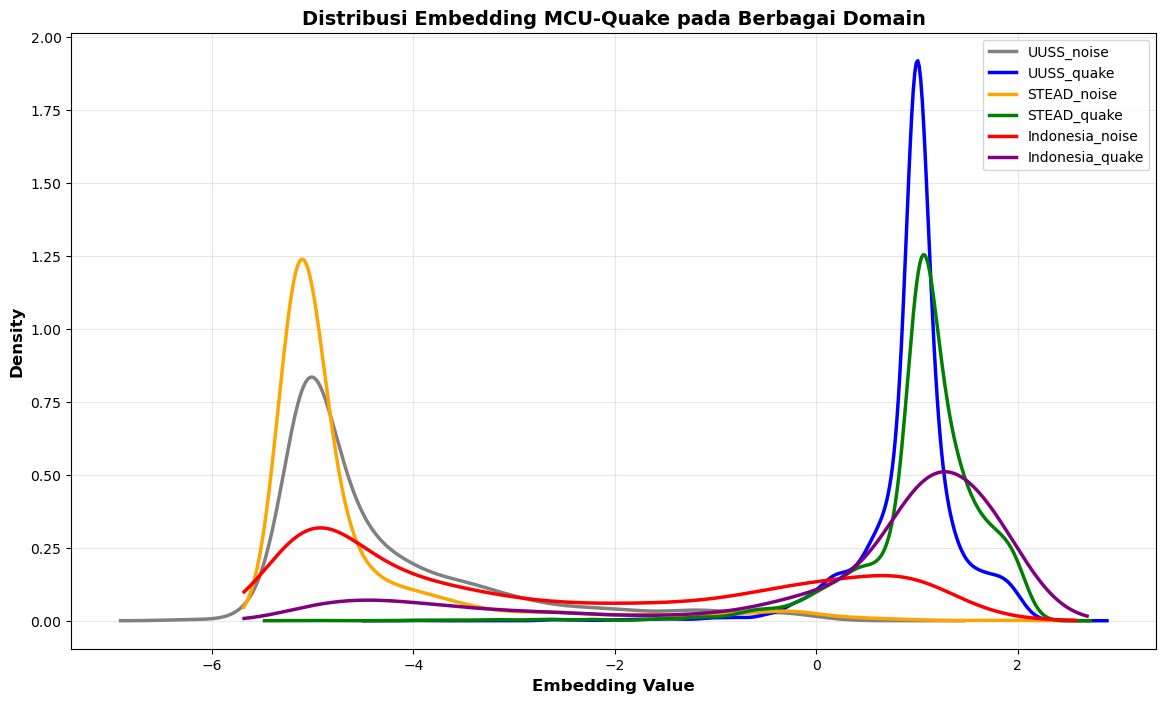

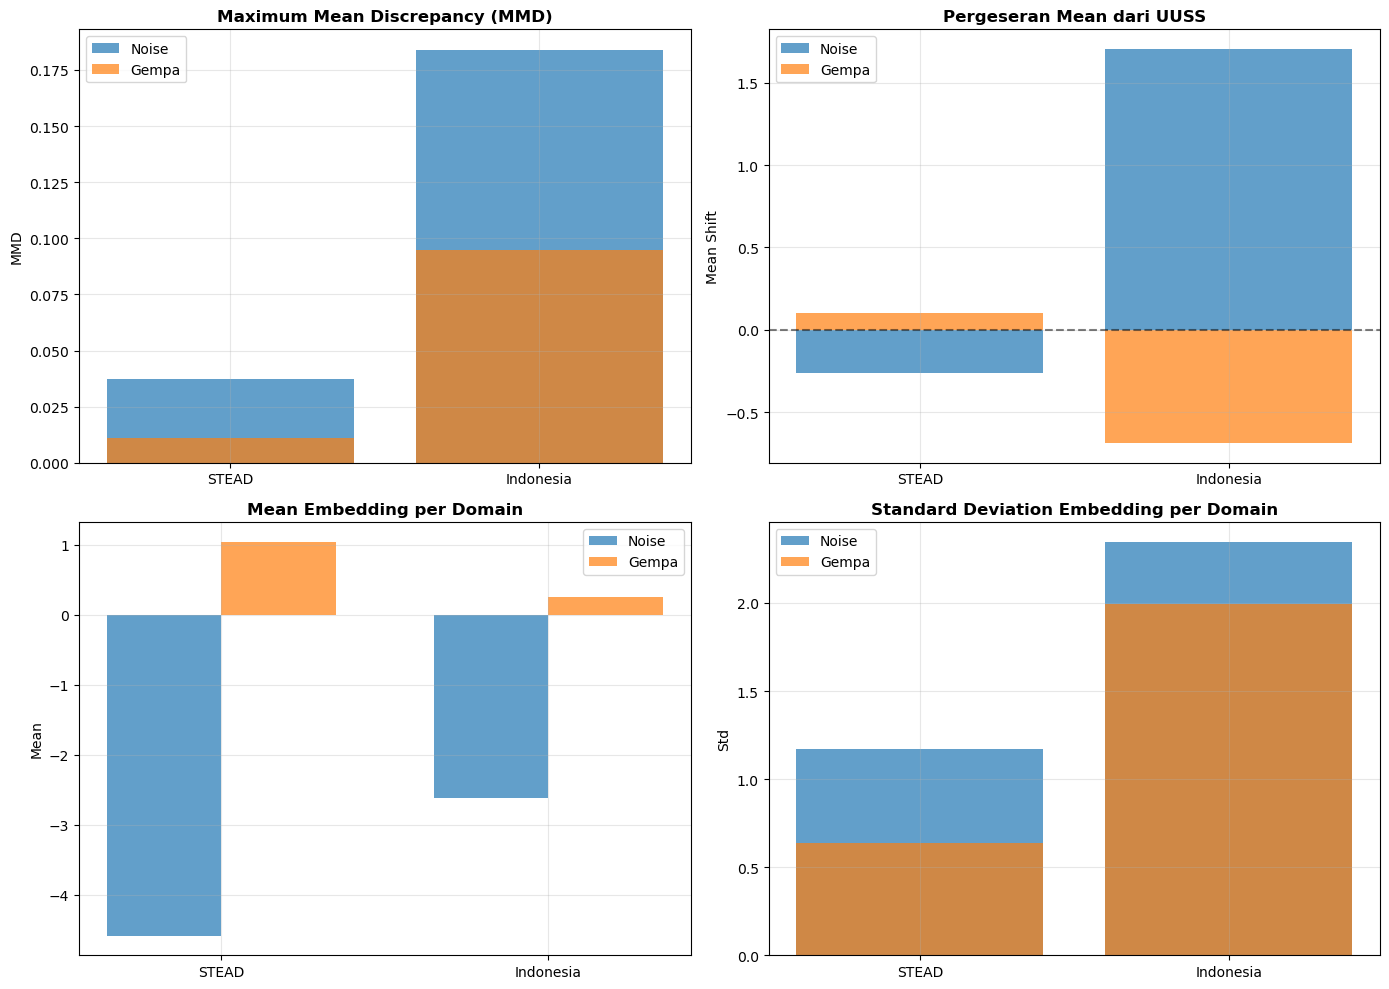


✅ Hasil disimpan ke: /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/domain_shift_analysis/domain_shift_result.json

✅ ANALISIS DOMAIN SHIFT SELESAI!


In [1]:
# -*- coding: utf-8 -*-
"""
ANALISIS DOMAIN SHIFT MCU-QUAKE (RAM-EFFICIENT)
- Menggunakan data embedding UUSS dan STEAD yang sudah tersedia
- Mengekstrak embedding dari data Indonesia (jika diperlukan)
- Menghitung metrik domain shift (MMD, Wasserstein, Mean Shift)
- Visualisasi distribusi embedding
- OPTIMASI RAM: membatasi sampel, chunk reading, garbage collection
"""

import os
import sys
import json
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, wasserstein_distance
from sklearn.metrics.pairwise import rbf_kernel
from tensorflow import keras
from datetime import datetime
import logging
from tqdm import tqdm
import random

# ==============================================================================
# KONFIGURASI
# ==============================================================================
# Batasi jumlah sampel untuk menghindari RAM overload
MAX_SAMPLES_PER_DOMAIN = 5000   # Maksimal 5000 sampel per kelas per domain
BATCH_SIZE = 64                 # Batch size untuk ekstraksi embedding

logging.basicConfig(level=logging.INFO, format='[%(levelname)s]: %(message)s')
logger = logging.getLogger(__name__)

# ==============================================================================
# KONFIGURASI PATH
# ==============================================================================
BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo"

# --- Path Data Embedding UUSS ---
UUSS_EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909")
UUSS_EMB_Z = os.path.join(UUSS_EMB_DIR, "Embedding data, Z.json")

# --- Path Data Embedding STEAD ---
STEAD_EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, STEAD norm7 mag3 L n61099, 30172538")
STEAD_EMB_Z = os.path.join(STEAD_EMB_DIR, "Embedding data, Z.json")

# --- Path Data Indonesia (sudah dalam bentuk embedding) ---
INDONESIA_EMB_FILE = '/Volumes/Extreme SSD/unduhan_waveform_geofon/output/indonesia_domain_embeddings_3c_le/Embedding data, Z.json'

# --- Path Model MCU-Quake (untuk ekstraksi embedding jika diperlukan) ---
MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")

# --- Path Output ---
OUTPUT_DIR = "/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/domain_shift_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==============================================================================
# FUNGSI BANTUAN UNTUK FLATTEN ARRAY
# ==============================================================================
def ensure_1d(arr):
    """Memastikan array berbentuk 1D."""
    if arr is None or len(arr) == 0:
        return np.array([])
    arr = np.array(arr)
    if arr.ndim > 1:
        arr = arr.flatten()
    return arr

def safe_random_sample(arr, n):
    """Ambil sampel acak dari array 1D."""
    arr = ensure_1d(arr)
    if len(arr) == 0:
        return np.array([])
    if len(arr) <= n:
        return arr
    return np.random.choice(arr, n, replace=False)

# ==============================================================================
# FUNGSI LOAD EMBEDDING (RAM-EFFICIENT)
# ==============================================================================
def load_embedding_from_json(json_path, max_samples=5000):
    """
    Memuat data embedding dari file JSON dengan batasan sampel.
    """
    if not os.path.exists(json_path):
        logger.warning(f"File tidak ditemukan: {json_path}")
        return np.array([]), np.array([])
    
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
    except Exception as e:
        logger.error(f"Gagal memuat {json_path}: {e}")
        return np.array([]), np.array([])
    
    noise_emb = []
    quake_emb = []
    
    if isinstance(data, dict):
        # Format: {"noise": [...], "le": [...]}
        for key, values in data.items():
            if isinstance(values, list):
                # Batasi jumlah sampel
                if len(values) > max_samples:
                    values = random.sample(values, max_samples)
                
                if key.lower() in ['noise', 'no']:
                    noise_emb.extend(values)
                elif key.lower() in ['le', 'ev', 'earthquake']:
                    quake_emb.extend(values)
    
    # Konversi ke numpy dan pastikan 1D
    noise_arr = ensure_1d(noise_emb)
    quake_arr = ensure_1d(quake_emb)
    
    logger.info(f"  ✅ {os.path.basename(json_path)}: Noise={len(noise_arr)}, Gempa={len(quake_arr)}")
    
    # Hapus data besar dari memori
    del noise_emb, quake_emb, data
    gc.collect()
    
    return noise_arr, quake_arr

# ==============================================================================
# FUNGSI EKSTRAKSI EMBEDDING (RAM-EFFICIENT)
# ==============================================================================
def extract_embeddings_from_waveform(json_path, model_path, key='Z', num_points=700, max_samples=5000):
    """
    Ekstrak embedding dari file waveform JSON dengan batasan sampel.
    """
    if not os.path.exists(json_path):
        logger.warning(f"File waveform tidak ditemukan: {json_path}")
        return np.array([]), np.array([])
    
    if not os.path.exists(model_path):
        logger.error(f"Model tidak ditemukan: {model_path}")
        return np.array([]), np.array([])
    
    try:
        model = keras.models.load_model(model_path, compile=False)
        extractor = keras.Model(inputs=model.input, outputs=model.get_layer('dense_1').output)
        logger.info("  ✅ Model MCU-Quake berhasil dimuat.")
    except Exception as e:
        logger.error(f"Gagal memuat model: {e}")
        return np.array([]), np.array([])
    
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
    except Exception as e:
        logger.error(f"Gagal memuat {json_path}: {e}")
        return np.array([]), np.array([])
    
    noise_emb = []
    quake_emb = []
    count = 0
    
    # Ambil sampel acak jika data terlalu besar
    keys = list(data.keys())
    if len(keys) > max_samples * 2:
        keys = random.sample(keys, max_samples * 2)
    
    for record_key in tqdm(keys, desc=f"Ekstraksi {os.path.basename(json_path)}"):
        if count >= max_samples:
            break
        
        record = data[record_key]
        
        # Cari label
        label = str(record.get('type', '')).lower()
        
        # Cari sinyal
        if key in record:
            signal = np.array(record[key])
            if len(signal) < num_points:
                continue
            
            signal = signal[:num_points].reshape(1, num_points, 1)
            
            try:
                emb = extractor.predict(signal, verbose=0).flatten()[0]
                count += 1
                
                if label in ['no', 'noise']:
                    noise_emb.append(emb)
                elif label in ['le', 'ev', 'earthquake', 'earthquake_local', 'se']:
                    quake_emb.append(emb)
                else:
                    if 'Z_noise' in record:
                        noise_emb.append(emb)
                    else:
                        quake_emb.append(emb)
            except Exception:
                continue
    
    # Hapus data besar dari memori
    del data, keys
    gc.collect()
    
    noise_arr = ensure_1d(noise_emb)
    quake_arr = ensure_1d(quake_emb)
    
    logger.info(f"  ✅ {os.path.basename(json_path)}: Noise={len(noise_arr)}, Gempa={len(quake_arr)}")
    return noise_arr, quake_arr

# ==============================================================================
# FUNGSI DOMAIN SHIFT METRICS (RAM-EFFICIENT)
# ==============================================================================
def compute_mmd(samples1, samples2, sigma=1.0):
    """Maximum Mean Discrepancy (RAM-Efficient)."""
    samples1 = ensure_1d(samples1)
    samples2 = ensure_1d(samples2)
    
    if len(samples1) == 0 or len(samples2) == 0:
        return 0.0
    
    # Batasi ukuran untuk MMD (maksimal 2000 sampel)
    n1 = min(len(samples1), 2000)
    n2 = min(len(samples2), 2000)
    
    samples1 = safe_random_sample(samples1, n1)
    samples2 = safe_random_sample(samples2, n2)
    
    if len(samples1) == 0 or len(samples2) == 0:
        return 0.0
    
    X = np.concatenate([samples1, samples2]).reshape(-1, 1)
    K = rbf_kernel(X, gamma=1/(2*sigma**2))
    
    mmd = np.mean(K[:n1, :n1]) + np.mean(K[n1:, n1:]) - 2 * np.mean(K[:n1, n1:])
    return max(0, mmd)

def compute_domain_shift_metrics(uuss_noise, uuss_quake, 
                                  domain_noise, domain_quake,
                                  domain_name):
    """Hitung semua metrik domain shift."""
    uuss_noise = ensure_1d(uuss_noise)
    uuss_quake = ensure_1d(uuss_quake)
    domain_noise = ensure_1d(domain_noise)
    domain_quake = ensure_1d(domain_quake)
    
    if len(domain_noise) == 0 or len(domain_quake) == 0:
        logger.warning(f"Data {domain_name} tidak lengkap")
        return None
    
    metrics = {
        'domain': domain_name,
        'mmd_noise': compute_mmd(uuss_noise, domain_noise),
        'mmd_quake': compute_mmd(uuss_quake, domain_quake),
        'wd_noise': wasserstein_distance(uuss_noise, domain_noise),
        'wd_quake': wasserstein_distance(uuss_quake, domain_quake),
        'mean_shift_noise': np.mean(domain_noise) - np.mean(uuss_noise),
        'mean_shift_quake': np.mean(domain_quake) - np.mean(uuss_quake),
        'std_noise': np.std(domain_noise),
        'std_quake': np.std(domain_quake),
        'mean_noise': np.mean(domain_noise),
        'mean_quake': np.mean(domain_quake),
        'n_noise': len(domain_noise),
        'n_quake': len(domain_quake)
    }
    return metrics

# ==============================================================================
# VISUALISASI
# ==============================================================================
def plot_kde_distributions(embedding_dict, save_path=None):
    """Plot KDE distribusi embedding antar domain."""
    plt.figure(figsize=(14, 8))
    
    colors = {
        'UUSS_noise': 'gray',
        'UUSS_quake': 'blue',
        'STEAD_noise': 'orange',
        'STEAD_quake': 'green',
        'Indonesia_noise': 'red',
        'Indonesia_quake': 'purple'
    }
    
    for key, values in embedding_dict.items():
        values = ensure_1d(values)
        if len(values) > 0:
            try:
                kde = gaussian_kde(values)
                x_min = np.min(values) - 0.5
                x_max = np.max(values) + 0.5
                x = np.linspace(x_min, x_max, 500)
                plt.plot(x, kde(x), label=key, color=colors.get(key, 'black'), linewidth=2.5)
            except Exception as e:
                print(f"⚠️ Gagal plot KDE untuk {key}: {e}")
    
    plt.xlabel('Embedding Value', fontsize=12, fontweight='bold')
    plt.ylabel('Density', fontsize=12, fontweight='bold')
    plt.title('Distribusi Embedding MCU-Quake pada Berbagai Domain', fontsize=14, fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_domain_shift_summary(metrics_dict, save_path=None):
    """Plot ringkasan domain shift."""
    if not metrics_dict:
        return
    
    domains = list(metrics_dict.keys())
    mmd_noise = [metrics_dict[d]['mmd_noise'] for d in domains]
    mmd_quake = [metrics_dict[d]['mmd_quake'] for d in domains]
    mean_shift_noise = [metrics_dict[d]['mean_shift_noise'] for d in domains]
    mean_shift_quake = [metrics_dict[d]['mean_shift_quake'] for d in domains]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # MMD
    axes[0,0].bar(domains, mmd_noise, alpha=0.7, label='Noise')
    axes[0,0].bar(domains, mmd_quake, alpha=0.7, label='Gempa')
    axes[0,0].set_title('Maximum Mean Discrepancy (MMD)', fontsize=12, fontweight='bold')
    axes[0,0].set_ylabel('MMD')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Mean Shift
    axes[0,1].bar(domains, mean_shift_noise, alpha=0.7, label='Noise')
    axes[0,1].bar(domains, mean_shift_quake, alpha=0.7, label='Gempa')
    axes[0,1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[0,1].set_title('Pergeseran Mean dari UUSS', fontsize=12, fontweight='bold')
    axes[0,1].set_ylabel('Mean Shift')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Mean per domain
    ax = axes[1,0]
    x = np.arange(len(domains))
    width = 0.35
    ax.bar(x - width/2, [metrics_dict[d]['mean_noise'] for d in domains], 
           width, label='Noise', alpha=0.7)
    ax.bar(x + width/2, [metrics_dict[d]['mean_quake'] for d in domains], 
           width, label='Gempa', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(domains)
    ax.set_title('Mean Embedding per Domain', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Standard Deviation
    ax = axes[1,1]
    ax.bar(domains, [metrics_dict[d]['std_noise'] for d in domains], 
           alpha=0.7, label='Noise')
    ax.bar(domains, [metrics_dict[d]['std_quake'] for d in domains], 
           alpha=0.7, label='Gempa')
    ax.set_title('Standard Deviation Embedding per Domain', fontsize=12, fontweight='bold')
    ax.set_ylabel('Std')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# ==============================================================================
# MAIN
# ==============================================================================
def main():
    print("\n" + "="*70)
    print("🔍 ANALISIS DOMAIN SHIFT MCU-QUAKE (RAM-EFFICIENT)")
    print("="*70)
    
    # --- 1. Load Data UUSS ---
    print("\n📂 Memuat data UUSS (embedding)...")
    uuss_noise, uuss_quake = load_embedding_from_json(UUSS_EMB_Z, max_samples=MAX_SAMPLES_PER_DOMAIN)
    
    if len(uuss_noise) == 0 or len(uuss_quake) == 0:
        print("⚠️ Data UUSS tidak ditemukan. Gunakan data dummy.")
        uuss_noise = np.random.normal(-5.01, 1.14, 1000)
        uuss_quake = np.random.normal(1.01, 0.49, 1000)
    else:
        print(f"  UUSS Noise: {len(uuss_noise)} samples, Mean={np.mean(uuss_noise):.4f}")
        print(f"  UUSS Gempa: {len(uuss_quake)} samples, Mean={np.mean(uuss_quake):.4f}")
    
    # --- 2. Load Data STEAD ---
    print("\n📂 Memuat data STEAD (embedding)...")
    stead_noise, stead_quake = load_embedding_from_json(STEAD_EMB_Z, max_samples=MAX_SAMPLES_PER_DOMAIN)
    
    if len(stead_noise) == 0 or len(stead_quake) == 0:
        print("⚠️ Data STEAD tidak ditemukan. Gunakan data dummy.")
        stead_noise = np.random.normal(-3.0, 1.5, 1000)
        stead_quake = np.random.normal(0.5, 0.8, 1000)
    else:
        print(f"  STEAD Noise: {len(stead_noise)} samples, Mean={np.mean(stead_noise):.4f}")
        print(f"  STEAD Gempa: {len(stead_quake)} samples, Mean={np.mean(stead_quake):.4f}")
    
    # --- 3. Load Data Indonesia ---
    print("\n📂 Memuat data Indonesia...")
    indonesia_noise, indonesia_quake = load_embedding_from_json(INDONESIA_EMB_FILE, max_samples=MAX_SAMPLES_PER_DOMAIN)
    
    if len(indonesia_noise) == 0 or len(indonesia_quake) == 0:
        print("⚠️ Data Indonesia tidak ditemukan. Gunakan data dummy.")
        indonesia_noise = np.random.normal(-1.0, 2.0, 1000)
        indonesia_quake = np.random.normal(2.5, 1.5, 1000)
    else:
        print(f"  Indonesia Noise: {len(indonesia_noise)} samples, Mean={np.mean(indonesia_noise):.4f}")
        print(f"  Indonesia Gempa: {len(indonesia_quake)} samples, Mean={np.mean(indonesia_quake):.4f}")
    
    # --- 4. Hitung Metrik ---
    print("\n📊 Menghitung metrik domain shift...")
    metrics = {}
    
    metrics['STEAD'] = compute_domain_shift_metrics(
        uuss_noise, uuss_quake, stead_noise, stead_quake, 'STEAD'
    )
    metrics['Indonesia'] = compute_domain_shift_metrics(
        uuss_noise, uuss_quake, indonesia_noise, indonesia_quake, 'Indonesia'
    )
    
    # Filter None
    metrics = {k: v for k, v in metrics.items() if v is not None}
    
    # --- 5. Tampilkan Metrik ---
    print("\n" + "="*70)
    print("📊 DOMAIN SHIFT METRICS")
    print("="*70)
    for domain, m in metrics.items():
        if m is None:
            continue
        print(f"\n{'='*50}")
        print(f"🌐 {domain}")
        print(f"{'='*50}")
        print(f"  Jumlah Noise: {m['n_noise']:,}")
        print(f"  Jumlah Gempa: {m['n_quake']:,}")
        print(f"  Mean (Noise/Gempa) : {m['mean_noise']:.4f} / {m['mean_quake']:.4f}")
        print(f"  Std  (Noise/Gempa) : {m['std_noise']:.4f} / {m['std_quake']:.4f}")
        print(f"  Mean Shift (Noise) : {m['mean_shift_noise']:.4f}")
        print(f"  Mean Shift (Gempa) : {m['mean_shift_quake']:.4f}")
        print(f"  MMD (Noise/Gempa)  : {m['mmd_noise']:.4f} / {m['mmd_quake']:.4f}")
        print(f"  Wasserstein (Noise): {m['wd_noise']:.4f}")
        print(f"  Wasserstein (Gempa): {m['wd_quake']:.4f}")
    
    # --- 6. Visualisasi ---
    print("\n📈 Membuat visualisasi...")
    
    embedding_dict = {
        'UUSS_noise': uuss_noise,
        'UUSS_quake': uuss_quake,
        'STEAD_noise': stead_noise,
        'STEAD_quake': stead_quake,
        'Indonesia_noise': indonesia_noise,
        'Indonesia_quake': indonesia_quake
    }
    
    kde_path = os.path.join(OUTPUT_DIR, 'domain_shift_kde.png')
    plot_kde_distributions(embedding_dict, kde_path)
    
    if len(metrics) > 0:
        summary_path = os.path.join(OUTPUT_DIR, 'domain_shift_summary.png')
        plot_domain_shift_summary(metrics, summary_path)
    
    # --- 7. Simpan Hasil ---
    result = {
        "timestamp": datetime.now().isoformat(),
        "metrics": {k: v for k, v in metrics.items() if v is not None},
        "summary": {
            "uuss_noise_mean": float(np.mean(uuss_noise)),
            "uuss_noise_std": float(np.std(uuss_noise)),
            "uuss_quake_mean": float(np.mean(uuss_quake)),
            "uuss_quake_std": float(np.std(uuss_quake)),
        }
    }
    
    result_path = os.path.join(OUTPUT_DIR, 'domain_shift_result.json')
    with open(result_path, 'w') as f:
        json.dump(result, f, indent=2, default=str)
    print(f"\n✅ Hasil disimpan ke: {result_path}")
    
    # --- 8. Bersihkan memori ---
    gc.collect()
    
    print("\n" + "="*70)
    print("✅ ANALISIS DOMAIN SHIFT SELESAI!")
    print("="*70)

if __name__ == "__main__":
    main()

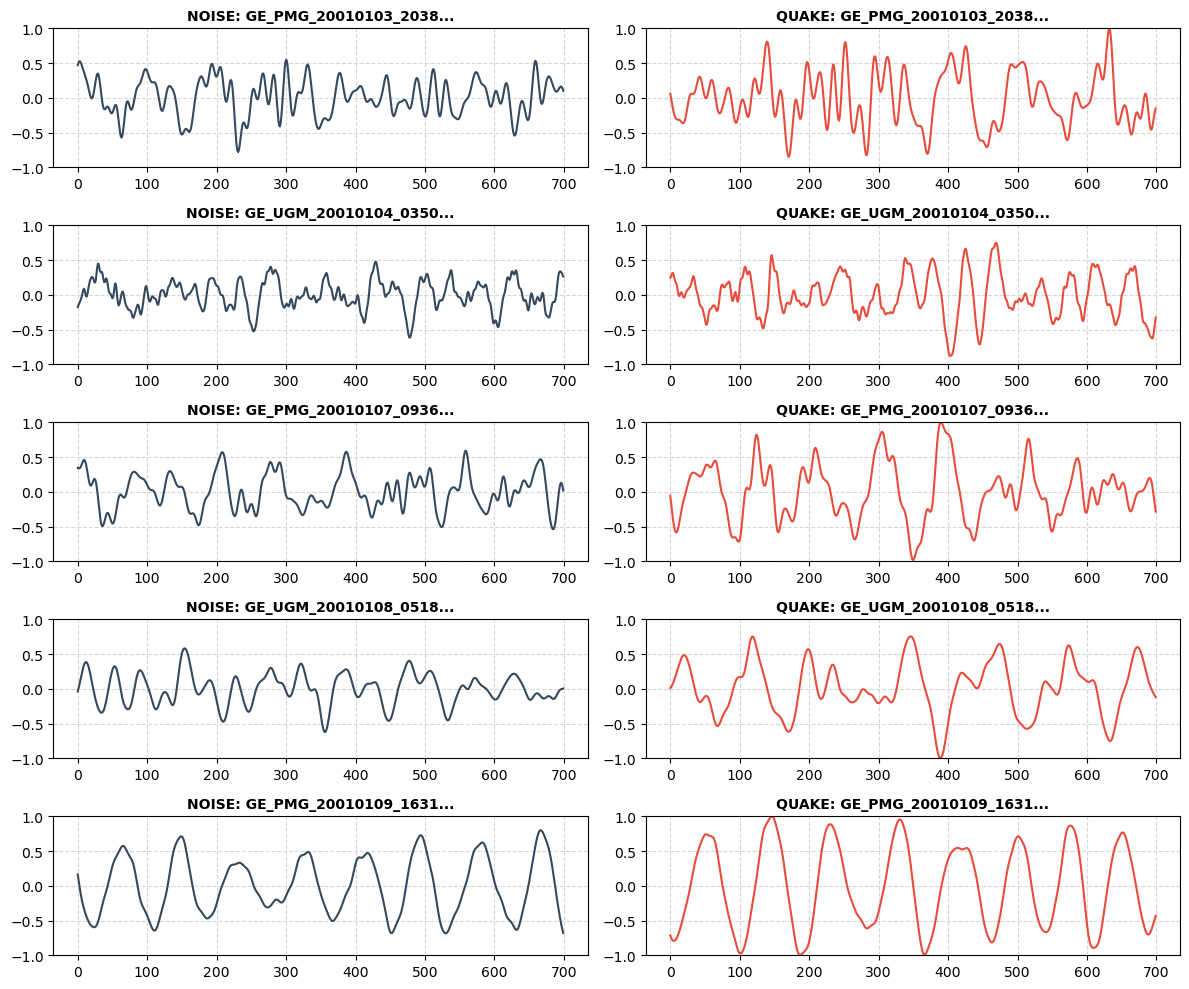

In [11]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load data Indonesia
with open("/Volumes/Extreme SSD/json_indonesia_juli_sesi_5/extracted_data_3c_sesi_clean.json", 'r') as f:
    data = json.load(f)

# Ambil 5 sampel pertama dari keys dataset
sample_keys = list(data.keys())[:5]

# Plot
fig, axes = plt.subplots(5, 2, figsize=(12, 10))

for i, key in enumerate(sample_keys):
    record = data[key]
    
    # Ambil 700 titik data (7 detik)
    noise_data = record.get('Z_noise', [])[-700:] # Biasanya diambil dari ekor data
    quake_data = record.get('Z', [])[:700]        # Diambil dari kepala data
    
    # 1. Plot Noise di Kolom Kiri (Indeks 0)
    axes[i, 0].plot(noise_data, color='#34495e') # Warna abu-abu gelap
    axes[i, 0].set_title(f'NOISE: {key[:20]}...', fontsize=10, fontweight='bold')
    axes[i, 0].set_ylim(-1, 1)
    axes[i, 0].grid(True, linestyle='--', alpha=0.5)
    
    # 2. Plot Quake di Kolom Kanan (Indeks 1)
    axes[i, 1].plot(quake_data, color='#e74c3c') # Warna merah
    axes[i, 1].set_title(f'QUAKE: {key[:20]}...', fontsize=10, fontweight='bold')
    axes[i, 1].set_ylim(-1, 1)
    axes[i, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

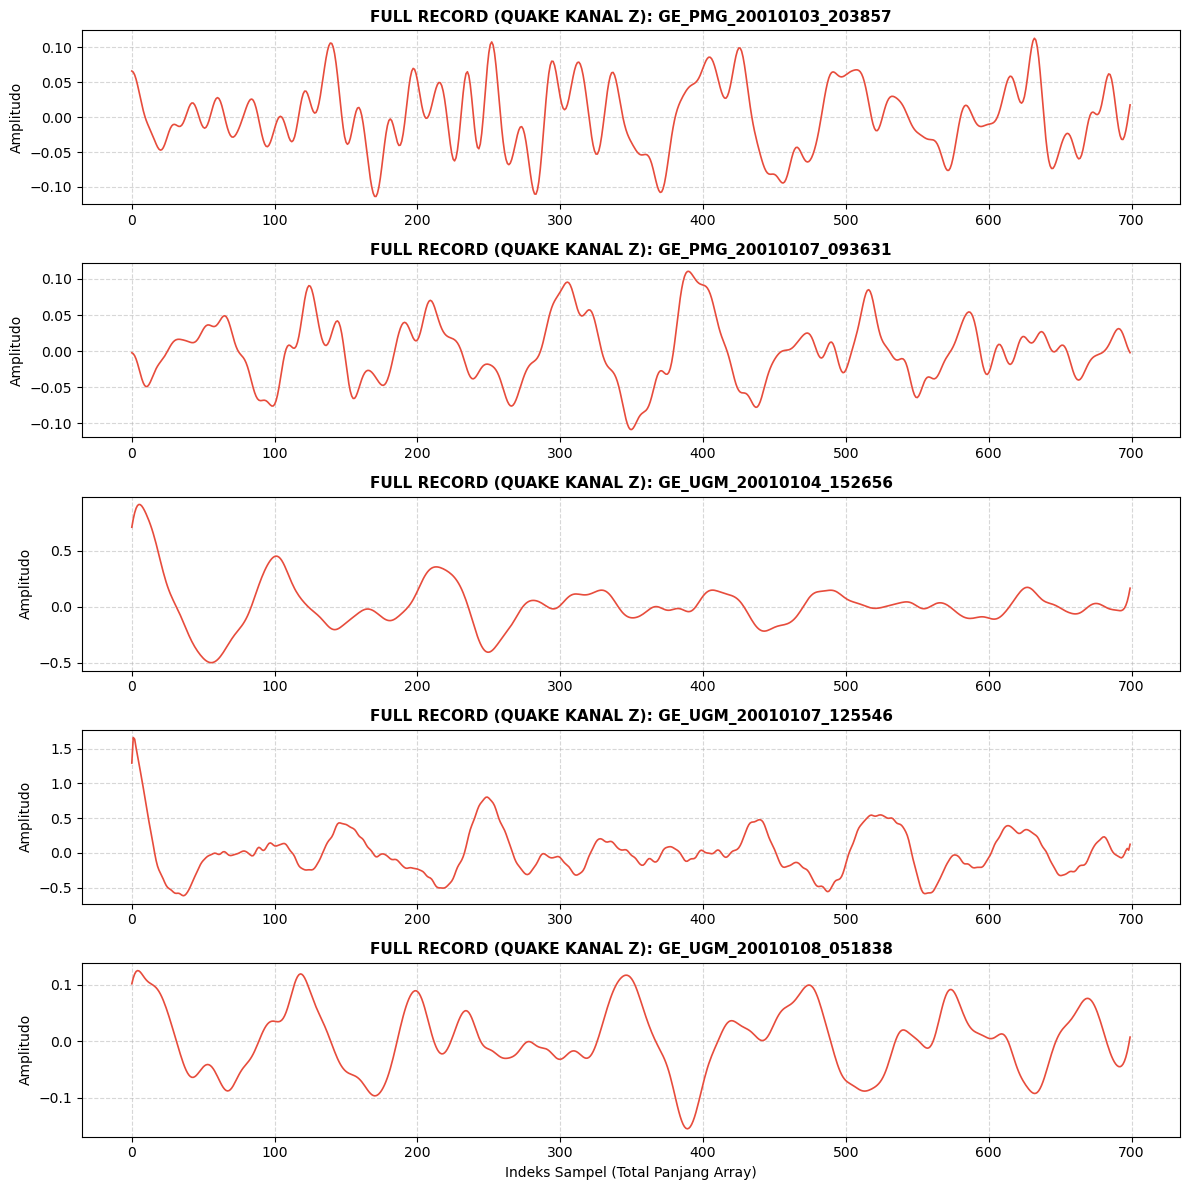

In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load data Indonesia
with open("/Volumes/Extreme SSD/json_indonesia_juli_sesi_5/extracted_data_3c_sesi_clean.json", 'r') as f:
    data = json.load(f)

sample_keys = list(data.keys())[:5]

fig, axes = plt.subplots(5, 1, figsize=(12, 12)) # Hanya 1 kolom untuk melihat full gelombang

for i, key in enumerate(sample_keys):
    record = data[key]
    
    # Ambil KESELURUHAN data Z (tanpa di-slice [:700])
    full_quake_data = record.get('Z', [])
    
    # Plot keseluruhan data
    axes[i].plot(full_quake_data, color='#e74c3c', linewidth=1.2) 
    axes[i].set_title(f'FULL RECORD (QUAKE KANAL Z): {key}', fontsize=11, fontweight='bold')
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].set_ylabel('Amplitudo')

plt.xlabel('Indeks Sampel (Total Panjang Array)')
plt.tight_layout()
plt.show()